# Machine learning using Apache Spark MLlib

Classification, a popular machine learning task, is the process of sorting input data into categories. It's the job of a classification algorithm to figure out how to assign labels to input data that you provide. For example, you can think of a machine learning algorithm that accepts stock information as input and divide the stock into two categories: stocks that you should sell and stocks that you should keep.

Logistic regression is an algorithm that you can use for classification. Spark's logistic regression API is useful for binary classification, or classifying input data into one of two groups. For more information about logistic regression, see [Wikipedia](https://en.wikipedia.org/wiki/Logistic_regression).

In summary, the process of logistic regression produces a logistic function that you can use to predict the probability that an input vector belongs in one group or the other.

## Predictive analysis using New York City taxi data

In this example, you use Spark to perform some predictive analysis on taxi-trip tip data from New York. The data is available through Azure Open Datasets. This subset of the dataset contains information about yellow taxi trips, including information about each trip, the start and end time and locations, the cost, and other interesting attributes.

In the following steps, you develop a model to predict whether a particular trip includes a tip or not.

### Create an Apache Spark machine learning model

In [1]:
import matplotlib.pyplot as plt
from datetime import datetime
from dateutil import parser
from pyspark.sql.functions import unix_timestamp, date_format, col, when
from pyspark.ml import Pipeline
from pyspark.ml import PipelineModel
from pyspark.ml.feature import RFormula
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.mllib.evaluation import BinaryClassificationMetrics
from pyspark.ml.evaluation import BinaryClassificationEvaluator

StatementMeta(spark7zvegk4, 0, 2, Finished, Available, Finished)

### Construct the input DataFrame

Because the raw data is in a Parquet format, you can use the Spark context to pull the file into memory as a DataFrame directly. Although the code in the following steps uses the default options, it's possible to force mapping of data types and other schema attributes if needed.

Run the following lines to create a Spark DataFrame by pasting the code into a new cell. This step retrieves the data via the Open Datasets API. Pulling all of this data generates about 1.5 billion rows.

In [2]:
from azureml.opendatasets import NycTlcYellow

from datetime import datetime
from dateutil import parser

end_date = parser.parse('2018-05-08 00:00:00')
start_date = parser.parse('2018-05-01 00:00:00')

nyc_tlc = NycTlcYellow(start_date=start_date, end_date=end_date)
filtered_df = spark.createDataFrame(nyc_tlc.to_pandas_dataframe())

StatementMeta(spark7zvegk4, 0, 3, Finished, Available, Finished)

[Info] read from /tmp/tmp8srlvfpx/https%3A/%2Fazureopendatastorage.azurefd.net/nyctlc/yellow/puYear=2018/puMonth=5/part-00000-tid-8898858832658823408-a1de80bd-eed3-4d11-b9d4-fa74bfbd47bc-426339-118.c000.snappy.parquet
[Info] read from /tmp/tmp8srlvfpx/https%3A/%2Fazureopendatastorage.azurefd.net/nyctlc/yellow/puYear=2018/puMonth=5/part-00001-tid-8898858832658823408-a1de80bd-eed3-4d11-b9d4-fa74bfbd47bc-426336-117.c000.snappy.parquet
[Info] read from /tmp/tmp8srlvfpx/https%3A/%2Fazureopendatastorage.azurefd.net/nyctlc/yellow/puYear=2018/puMonth=5/part-00002-tid-8898858832658823408-a1de80bd-eed3-4d11-b9d4-fa74bfbd47bc-426334-119.c000.snappy.parquet
[Info] read from /tmp/tmp8srlvfpx/https%3A/%2Fazureopendatastorage.azurefd.net/nyctlc/yellow/puYear=2018/puMonth=5/part-00003-tid-8898858832658823408-a1de80bd-eed3-4d11-b9d4-fa74bfbd47bc-426340-115.c000.snappy.parquet
[Info] read from /tmp/tmp8srlvfpx/https%3A/%2Fazureopendatastorage.azurefd.net/nyctlc/yellow/puYear=2018/puMonth=5/part-00004-ti

The downside to simple filtering is that, from a statistical perspective, it might introduce bias into the data. Another approach is to use the sampling built into Spark.

The following code reduces the dataset to about 2,000 rows, if it's applied after the preceding code. You can use this sampling step instead of the simple filter or in conjunction with the simple filter.

In [3]:
# To make development easier, faster, and less expensive, downsample for now
sampled_taxi_df = filtered_df.sample(True, 0.001, seed=1234)

StatementMeta(spark7zvegk4, 0, 4, Finished, Available, Finished)

It's now possible to look at the data to see what was read. It's normally better to review data with a subset rather than the full set, depending on the size of the dataset.

The following code offers two ways to view the data. The first way is basic. The second way provides a much richer grid experience, along with the capability to visualize the data graphically.

In [4]:
#sampled_taxi_df.show(5)
display(sampled_taxi_df)

StatementMeta(spark7zvegk4, 0, 5, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 3a7fb938-475e-4b97-9daa-c6de2be4513e)

Depending on the size of the generated dataset, and your need to experiment or run the notebook many times, you might want to cache the dataset locally in the workspace. There are three ways to perform explicit caching:

- Save the DataFrame locally as a file.
- Save the DataFrame as a temporary table or view.
- Save the DataFrame as a permanent table.
- The first two of these approaches are included in the following code examples.

Creating a temporary table or view provides different access paths to the data, but it lasts only for the duration of the Spark instance session.

In [5]:
sampled_taxi_df.createOrReplaceTempView("nytaxi")

StatementMeta(spark7zvegk4, 0, 6, Finished, Available, Finished)

### Prepare the data

The data in its raw form is often not suitable for passing directly to a model. You must perform a series of actions on the data to get it into a state where the model can consume it.

In the following code, you perform four classes of operations:

- The removal of outliers or incorrect values through filtering.
- The removal of columns, which are not needed.
- The creation of new columns derived from the raw data to make the model work more effectively. This operation is sometimes called featurization.
- Labeling. Because you're undertaking binary classification (will there be a tip or not on a given trip), there's a need to convert the tip amount into a 0 or 1 value.

In [6]:
taxi_df = sampled_taxi_df.select('totalAmount', 'fareAmount', 'tipAmount', 'paymentType', 'rateCodeId', 'passengerCount'\
                                , 'tripDistance', 'tpepPickupDateTime', 'tpepDropoffDateTime'\
                                , date_format('tpepPickupDateTime', 'hh').alias('pickupHour')\
                                , date_format('tpepPickupDateTime', 'EEEE').alias('weekdayString')\
                                , (unix_timestamp(col('tpepDropoffDateTime')) - unix_timestamp(col('tpepPickupDateTime'))).alias('tripTimeSecs')\
                                , (when(col('tipAmount') > 0, 1).otherwise(0)).alias('tipped')
                                )\
                        .filter((sampled_taxi_df.passengerCount > 0) & (sampled_taxi_df.passengerCount < 8)\
                                & (sampled_taxi_df.tipAmount >= 0) & (sampled_taxi_df.tipAmount <= 25)\
                                & (sampled_taxi_df.fareAmount >= 1) & (sampled_taxi_df.fareAmount <= 250)\
                                & (sampled_taxi_df.tipAmount < sampled_taxi_df.fareAmount)\
                                & (sampled_taxi_df.tripDistance > 0) & (sampled_taxi_df.tripDistance <= 100)\
                                & (sampled_taxi_df.rateCodeId <= 5)
                                & (sampled_taxi_df.paymentType.isin({"1", "2"}))
                                )

StatementMeta(spark7zvegk4, 0, 7, Finished, Available, Finished)

You then make a second pass over the data to add the final features.

In [7]:
taxi_featurised_df = taxi_df.select('totalAmount', 'fareAmount', 'tipAmount', 'paymentType', 'passengerCount'\
                                                , 'tripDistance', 'weekdayString', 'pickupHour','tripTimeSecs','tipped'\
                                                , when((taxi_df.pickupHour <= 6) | (taxi_df.pickupHour >= 20),"Night")\
                                                .when((taxi_df.pickupHour >= 7) & (taxi_df.pickupHour <= 10), "AMRush")\
                                                .when((taxi_df.pickupHour >= 11) & (taxi_df.pickupHour <= 15), "Afternoon")\
                                                .when((taxi_df.pickupHour >= 16) & (taxi_df.pickupHour <= 19), "PMRush")\
                                                .otherwise(0).alias('trafficTimeBins')
                                              )\
                                       .filter((taxi_df.tripTimeSecs >= 30) & (taxi_df.tripTimeSecs <= 7200))

StatementMeta(spark7zvegk4, 0, 8, Finished, Available, Finished)

### Create a logistic regression model

The final task is to convert the labeled data into a format that can be analyzed through logistic regression. The input to a logistic regression algorithm needs to be a set of _label/feature vector pairs_, where the feature vector is a vector of numbers that represent the input point.

So, you need to convert the categorical columns into numbers. Specifically, you need to convert the `trafficTimeBins` and `weekdayString` columns into integer representations. There are multiple approaches to performing the conversion. The following example takes the `OneHotEncoder` approach, which is common.

In [8]:
# Because the sample uses an algorithm that works only with numeric features, convert them so they can be consumed
sI1 = StringIndexer(inputCol="trafficTimeBins", outputCol="trafficTimeBinsIndex")
en1 = OneHotEncoder(dropLast=False, inputCol="trafficTimeBinsIndex", outputCol="trafficTimeBinsVec")
sI2 = StringIndexer(inputCol="weekdayString", outputCol="weekdayIndex")
en2 = OneHotEncoder(dropLast=False, inputCol="weekdayIndex", outputCol="weekdayVec")

# Create a new DataFrame that has had the encodings applied
encoded_final_df = Pipeline(stages=[sI1, en1, sI2, en2]).fit(taxi_featurised_df).transform(taxi_featurised_df)

StatementMeta(spark7zvegk4, 0, 9, Finished, Available, Finished)

> This action results in a new DataFrame with all columns in the right format to train a model.

### Train a logistic regression model

The first task is to split the dataset into a training set and a testing or validation set. The split here is arbitrary. Experiment with different split settings to see if they affect the model.

In [9]:
# Decide on the split between training and testing data from the DataFrame
trainingFraction = 0.7
testingFraction = (1-trainingFraction)
seed = 1234

# Split the DataFrame into test and training DataFrames
train_data_df, test_data_df = encoded_final_df.randomSplit([trainingFraction, testingFraction], seed=seed)

StatementMeta(spark7zvegk4, 0, 10, Finished, Available, Finished)

Now that there are two DataFrames, the next task is to create the model formula and run it against the training DataFrame. Then you can validate against the testing DataFrame. Experiment with different versions of the model formula to see the impact of different combinations.

In [10]:
## Create a new logistic regression object for the model
logReg = LogisticRegression(maxIter=10, regParam=0.3, labelCol = 'tipped')

## The formula for the model
classFormula = RFormula(formula="tipped ~ pickupHour + weekdayVec + passengerCount + tripTimeSecs + tripDistance + fareAmount + paymentType+ trafficTimeBinsVec")

## Undertake training and create a logistic regression model
lrModel = Pipeline(stages=[classFormula, logReg]).fit(train_data_df)

## Saving the model is optional, but it's another form of inter-session cache
datestamp = datetime.now().strftime('%m-%d-%Y-%s')
fileName = "lrModel_" + datestamp
logRegDirfilename = fileName
lrModel.save(logRegDirfilename)

## Predict tip 1/0 (yes/no) on the test dataset; evaluation using area under ROC
predictions = lrModel.transform(test_data_df)
predictionAndLabels = predictions.select("label","prediction").rdd
metrics = BinaryClassificationMetrics(predictionAndLabels)
print("Area under ROC = %s" % metrics.areaUnderROC)

StatementMeta(spark7zvegk4, 0, 11, Finished, Available, Finished)

Area under ROC = 0.9751491053677932


### Create a visual representation of the prediction

You can now construct a final visualization to help you reason about the results of this test. An [ROC curve](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) is one way to review the result.

StatementMeta(spark7zvegk4, 0, 12, Finished, Available, Finished)

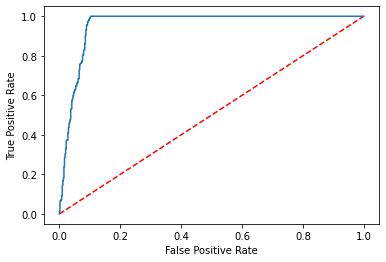

In [11]:
## Plot the ROC curve; no need for pandas, because this uses the modelSummary object
modelSummary = lrModel.stages[-1].summary

plt.plot([0, 1], [0, 1], 'r--')
plt.plot(modelSummary.roc.select('FPR').collect(),
         modelSummary.roc.select('TPR').collect())
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()